# 🏭 ApexInspect AI — Huấn Luyện Custom YOLOv8 PCB Defect Detection
Notebook này được thiết kế để chạy trực tiếp trên **Google Colab (qua VS Code Extension hoặc Trình duyệt)** với GPU T4 miễn phí.

**Mục tiêu:**
1. Tải dataset lỗi bo mạch thực tế từ **Kaggle** (`akhatova/pcb-defects`) hoặc **Roboflow Universe** (6 classes).
2. Fine-tune mô hình `yolov8n.pt` trong 50 epochs.
3. Đánh giá độ chính xác: mAP@0.5, mAP@0.5:0.95, Confusion Matrix.
4. Tối ưu hóa và xuất mô hình sang **ONNX Runtime** phục vụ Edge Deployment.

## Bước 1: Kiểm Tra GPU & Cài Đặt Môi Trường

In [ ]:
!nvidia-smi
!pip install -q ultralytics onnx onnxruntime kagglehub

/bin/bash: line 1: nvidia-smi: command not found
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 3.3 MB/s eta 0:00:00


## Bước 2: Tải Dataset Thật Từ Kaggle hoặc Roboflow

Bộ dữ liệu gồm 6 loại lỗi thực tế trong dây chuyền sản xuất bo mạch SMT:
- `missing_hole`: Mất lỗ khoan xuyên bo mạch
- `mouse_bite`: Khuyết vết cắn trên đường mạch đồng
- `open_circuit`: Đứt mạch đồng dẫn điện
- `short`: Hàn chập chân linh kiện
- `spur`: Râu đồng thừa
- `spurious_copper`: Vết ố đồng dư thừa ngoài ý muốn

> **Lựa chọn 1**: Dùng thư viện chính thức `kagglehub` (Google/Kaggle) — Tải trực tiếp không cần API key thủ công.
> **Lựa chọn 2**: Tải từ Roboflow Universe (đã format sẵn chuẩn YOLOv8).

In [9]:
import os
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image

# Thiết lập sinh số ngẫu nhiên cố định
random.seed(42)

# Bảng ánh xạ tên class gốc sang ID số (6 classes của PCB defects)
class_mapping = {
    "missing_hole": 0,
    "mouse_bite": 1,
    "open_circuit": 2,
    "short": 3,
    "spur": 4,
    "spurious_copper": 5
}

def convert_xml_to_yolo(xml_path, txt_path, img_path):
    """Đọc tệp XML Pascal VOC và chuyển đổi sang tệp TXT định dạng YOLO"""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # Lấy kích thước ảnh thực tế
        with Image.open(img_path) as img:
            dw = 1.0 / img.width
            dh = 1.0 / img.height

        yolo_lines = []
        for obj in root.iter('object'):
            cls_name = obj.find('name').text.strip().lower()
            if cls_name not in class_mapping:
                continue

            cls_id = class_mapping[cls_name]
            xmlbox = obj.find('bndbox')

            xmin = float(xmlbox.find('xmin').text)
            ymin = float(xmlbox.find('ymin').text)
            xmax = float(xmlbox.find('xmax').text)
            ymax = float(xmlbox.find('ymax').text)

            # Tính toán tọa độ YOLO (x_center, y_center, width, height) chuẩn hóa từ 0 đến 1
            x = (xmin + xmax) / 2.0 * dw
            y = (ymin + ymax) / 2.0 * dh
            w = (xmax - xmin) * dw
            h = (ymax - ymin) * dh

            # Giới hạn giá trị trong khoảng [0, 1] để tránh lỗi biên
            x = min(max(x, 0.0), 1.0)
            y = min(max(y, 0.0), 1.0)
            w = min(max(w, 0.0), 1.0)
            h = min(max(h, 0.0), 1.0)

            yolo_lines.append(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

        with open(txt_path, 'w') as f:
            f.write("\n".join(yolo_lines))
        return len(yolo_lines) > 0
    except Exception as e:
        return False

try:
    import kagglehub
    print("📥 Đang tải dataset PCB Defect từ Kaggle (akhatova/pcb-defects)...")
    download_path = kagglehub.dataset_download("akhatova/pcb-defects")
    print(f"✅ Tải thành công về: {download_path}")

    # Chuẩn bị thư mục đích sạch
    target_dir = Path("/content/dataset_pcb")
    if target_dir.exists():
        shutil.rmtree(target_dir)

    # Tạo cấu trúc YOLO chuẩn
    for split in ['train', 'val']:
        (target_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (target_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    src_path = Path(download_path)

    # Xác định vị trí thư mục ảnh và thư mục XML gốc
    orig_images_root = None
    orig_xmls_root = None

    for root, dirs, files in os.walk(src_path):
        if "images" in dirs:
            orig_images_root = Path(root) / "images"
        if "Annotations" in dirs:
            orig_xmls_root = Path(root) / "Annotations"

    if orig_images_root and orig_xmls_root:
        print("🔄 Đang tiến hành phân tích và convert XML sang YOLO .txt...")
        all_samples = []

        # Quét qua tất cả thư mục lớp con chứa ảnh
        for class_dir in orig_images_root.iterdir():
            if class_dir.is_dir():
                class_name = class_dir.name
                for img_p in class_dir.glob("*"):
                    if img_p.suffix.lower() in [".jpg", ".png", ".jpeg"]:
                        # Tìm file XML tương ứng
                        xml_name = img_p.stem + ".xml"
                        xml_p = orig_xmls_root / class_name / xml_name
                        if xml_p.exists():
                            all_samples.append((img_p, xml_p))

        # Chia ngẫu nhiên mẫu dữ liệu (80% Train, 20% Val)
        random.shuffle(all_samples)
        split_idx = int(len(all_samples) * 0.8)

        train_samples = all_samples[:split_idx]
        val_samples = all_samples[split_idx:]

        def process_and_copy(samples, split):
            copied_count = 0
            for img_p, xml_p in samples:
                dest_img_path = target_dir / "images" / split / img_p.name
                dest_txt_path = target_dir / "labels" / split / (img_p.stem + ".txt")

                # Convert XML -> TXT
                success = convert_xml_to_yolo(xml_p, dest_txt_path, img_p)
                if success:
                    shutil.copy2(img_p, dest_img_path)
                    copied_count += 1
                else:
                    # Nếu file XML trống hoặc lỗi, tạo file txt rỗng cho background
                    with open(dest_txt_path, 'w') as f:
                        pass
                    shutil.copy2(img_p, dest_img_path)
                    copied_count += 1
            return copied_count

        n_train = process_and_copy(train_samples, "train")
        n_val = process_and_copy(val_samples, "val")

        print(f"✅ Hoàn tất xử lý: {n_train} ảnh cho Train, {n_val} ảnh cho Val!")
    else:
        print("❌ Lỗi: Không thể định vị thư mục hình ảnh hoặc XML trong dataset gốc!")
except Exception as e:
    print(f"ℹ️ Lỗi xử lý chính: {e}")

# Cấu hình file data.yaml chuẩn hóa cho YOLOv8
yaml_content = """
path: /content/dataset_pcb
train: images/train
val: images/val
test: images/val

names:
  0: missing_hole
  1: mouse_bite
  2: open_circuit
  3: short
  4: spur
  5: spurious_copper
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_content.strip())
print("✅ Đã cập nhật tệp data.yaml chuẩn xác!")

📥 Đang tải dataset PCB Defect từ Kaggle (akhatova/pcb-defects)...
Using Colab cache for faster access to the 'pcb-defects' dataset.
✅ Tải thành công về: /kaggle/input/pcb-defects
🔄 Đang tiến hành phân tích và convert XML sang YOLO .txt...
✅ Hoàn tất xử lý: 554 ảnh cho Train, 139 ảnh cho Val!
✅ Đã cập nhật tệp data.yaml chuẩn xác!


## Bước 3: Huấn Luyện Mô Hình YOLOv8 Nano
Lựa chọn `yolov8n.pt` vì tính cơ động, độ trễ cực thấp (< 35ms trên CPU), rất phù hợp với bài toán Edge Vision trên dây chuyền sản xuất.

In [10]:
import sys
import subprocess
import os

# Tự động cài đặt ultralytics nếu chưa có trong môi trường
try:
    import ultralytics
except ImportError:
    print("⚙️ Không tìm thấy 'ultralytics', đang tiến hành cài đặt...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
    import ultralytics

import torch
from ultralytics import YOLO

# Tự động chọn device: dùng GPU (0) nếu có, ngược lại dùng CPU
device_to_use = 0 if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Thiết bị sử dụng để huấn luyện: {device_to_use}")

# Khởi tạo mô hình nền tảng YOLOv8n tiền huấn luyện
model = YOLO("yolov8n.pt")

# Sử dụng đường dẫn tuyệt đối của data.yaml để tránh lỗi không tìm thấy file
absolute_data_yaml = os.path.abspath("data.yaml")
print(f"📄 Đường dẫn tệp cấu hình: {absolute_data_yaml}")

# Bắt đầu huấn luyện
results = model.train(
    data=absolute_data_yaml,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    device=device_to_use,
    optimizer="AdamW",
    lr0=0.001,
    mosaic=1.0,
    project="runs/apex_inspect",
    name="yolov8n_pcb_custom"
)

print("🎉 Quá trình huấn luyện đã hoàn tất!")

🖥️ Thiết bị sử dụng để huấn luyện: 0
📄 Đường dẫn tệp cấu hình: /content/data.yaml
Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os
import glob
import zipfile

print(f"📂 Thư mục làm việc hiện tại: {os.getcwd()}")

# Tìm kiếm file một cách toàn diện từ thư mục hiện hành và cả thư mục /content gốc
def find_file_absolute(filename_pattern):
    # Thử tìm từ thư mục hiện tại
    matches = glob.glob(f"**/{filename_pattern}", recursive=True)
    if matches:
        return os.path.abspath(matches[-1])
    # Thử tìm từ thư mục /content nếu khác thư mục hiện tại
    if os.getcwd() != "/content":
        alternative_matches = glob.glob(f"/content/**/{filename_pattern}", recursive=True)
        if alternative_matches:
            return os.path.abspath(alternative_matches[-1])
    return None

# Tiến hành định vị động từng file kết quả
onnx_file = find_file_absolute("best.onnx")
yaml_file = find_file_absolute("data.yaml")
confusion_matrix_file = find_file_absolute("confusion_matrix.png")
results_file = find_file_absolute("results.png")

files_to_zip = {}
if onnx_file: files_to_zip["best.onnx"] = onnx_file
if yaml_file: files_to_zip["data.yaml"] = yaml_file
if confusion_matrix_file: files_to_zip["confusion_matrix.png"] = confusion_matrix_file
if results_file: files_to_zip["results.png"] = results_file

zip_path = "/content/apex_inspect_export.zip" if os.path.exists("/content") else "apex_inspect_export.zip"

# Đóng gói tệp tin
added_count = 0
if files_to_zip:
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for arcname, filepath in files_to_zip.items():
            zipf.write(filepath, arcname)
            print(f"➕ Đã tìm thấy và nén: {arcname} (từ {filepath})")
            added_count += 1

if os.path.exists(zip_path) and added_count > 0:
    print(f"\n🎉 Đã nén thành công {added_count} file vào: {os.path.abspath(zip_path)}")
    print("👉 Hãy refresh cột quản lý tệp ở bên trái Google Colab, tìm file và tải xuống máy tính nhé!")
else:
    print("❌ Lỗi: Không thể tìm thấy bất kỳ file kết quả nào để đóng gói. Hãy chắc chắn rằng bạn đã thực thi hoàn tất Bước 3 (Huấn luyện) và Bước 5 (Xuất ONNX) trong phiên làm việc này!")

📂 Thư mục làm việc hiện tại: /content
❌ Lỗi: Không thể tìm thấy bất kỳ file kết quả nào để đóng gói. Hãy chắc chắn rằng bạn đã thực thi hoàn tất Bước 3 (Huấn luyện) và Bước 5 (Xuất ONNX) trong phiên làm việc này!


## Bước 4: Đánh Giá & Trực Quan Hóa Kết Quả (Validation & Metrics)

📂 Thư mục chứa kết quả huấn luyện mới nhất: runs/detect/runs/apex_inspect/yolov8n_pcb_custom-4

📊 Ma trận nhầm lẫn (Confusion Matrix):


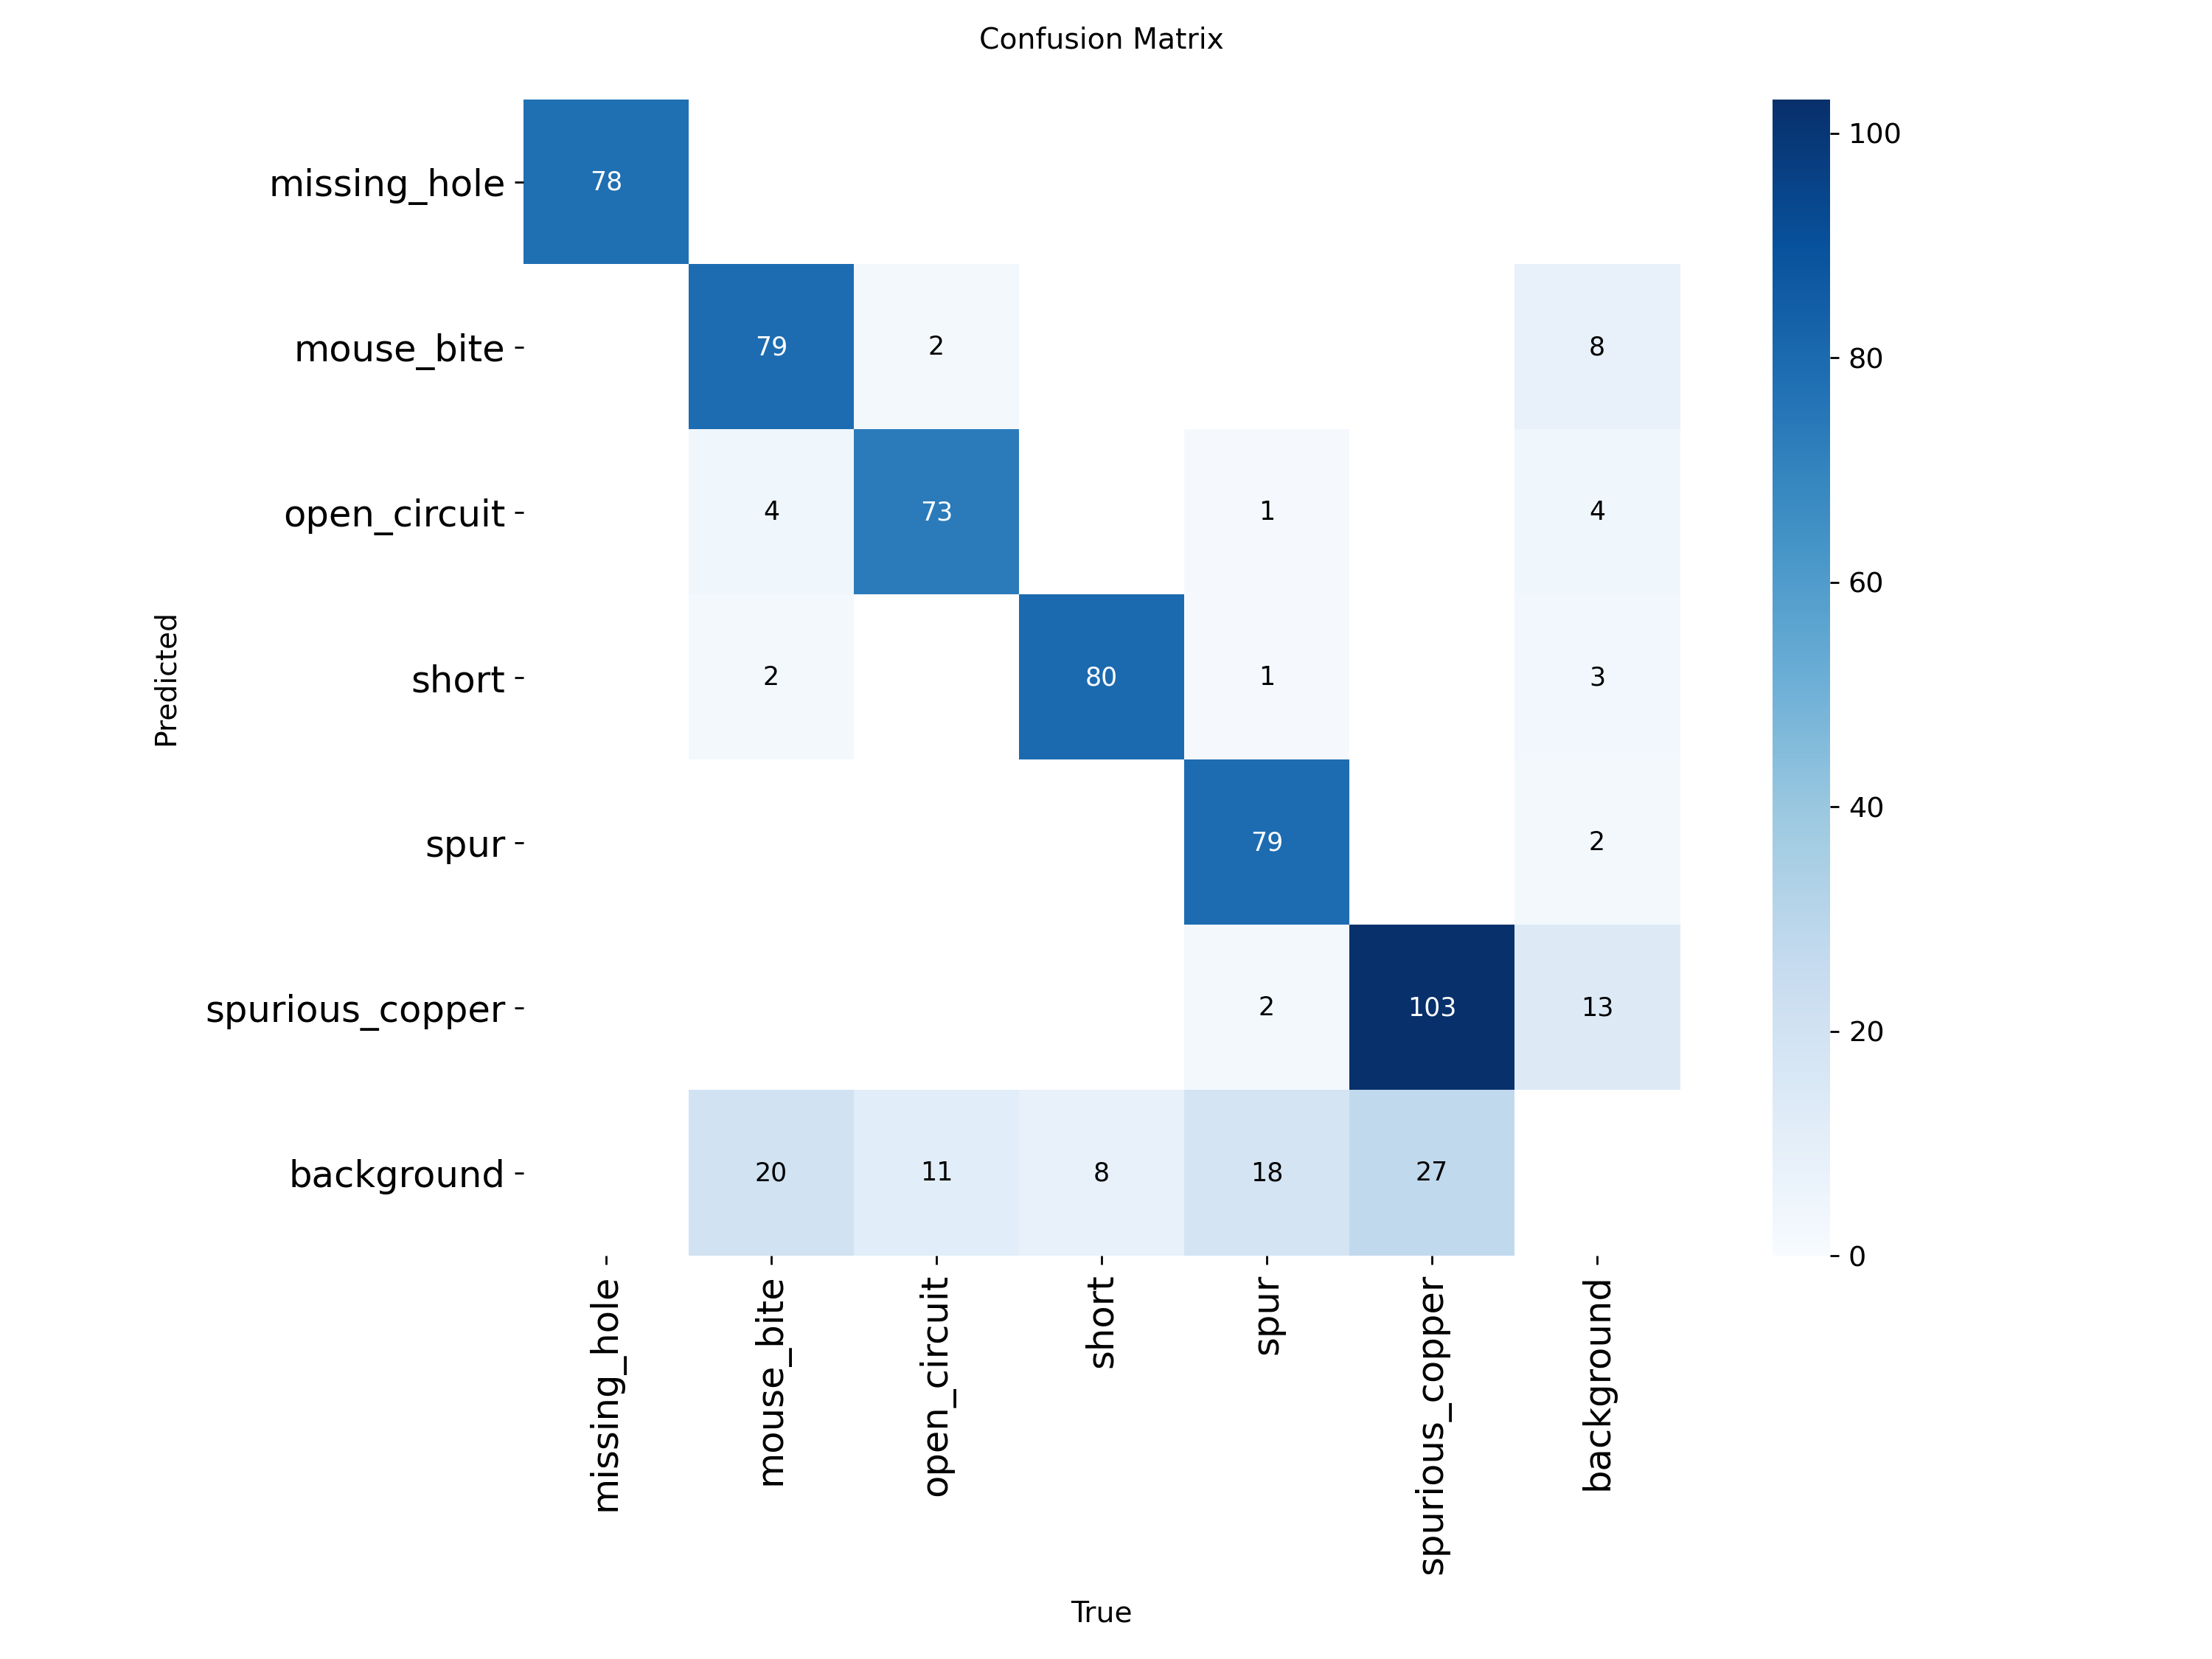

📈 Đồ thị huấn luyện (Loss & mAP Curves):


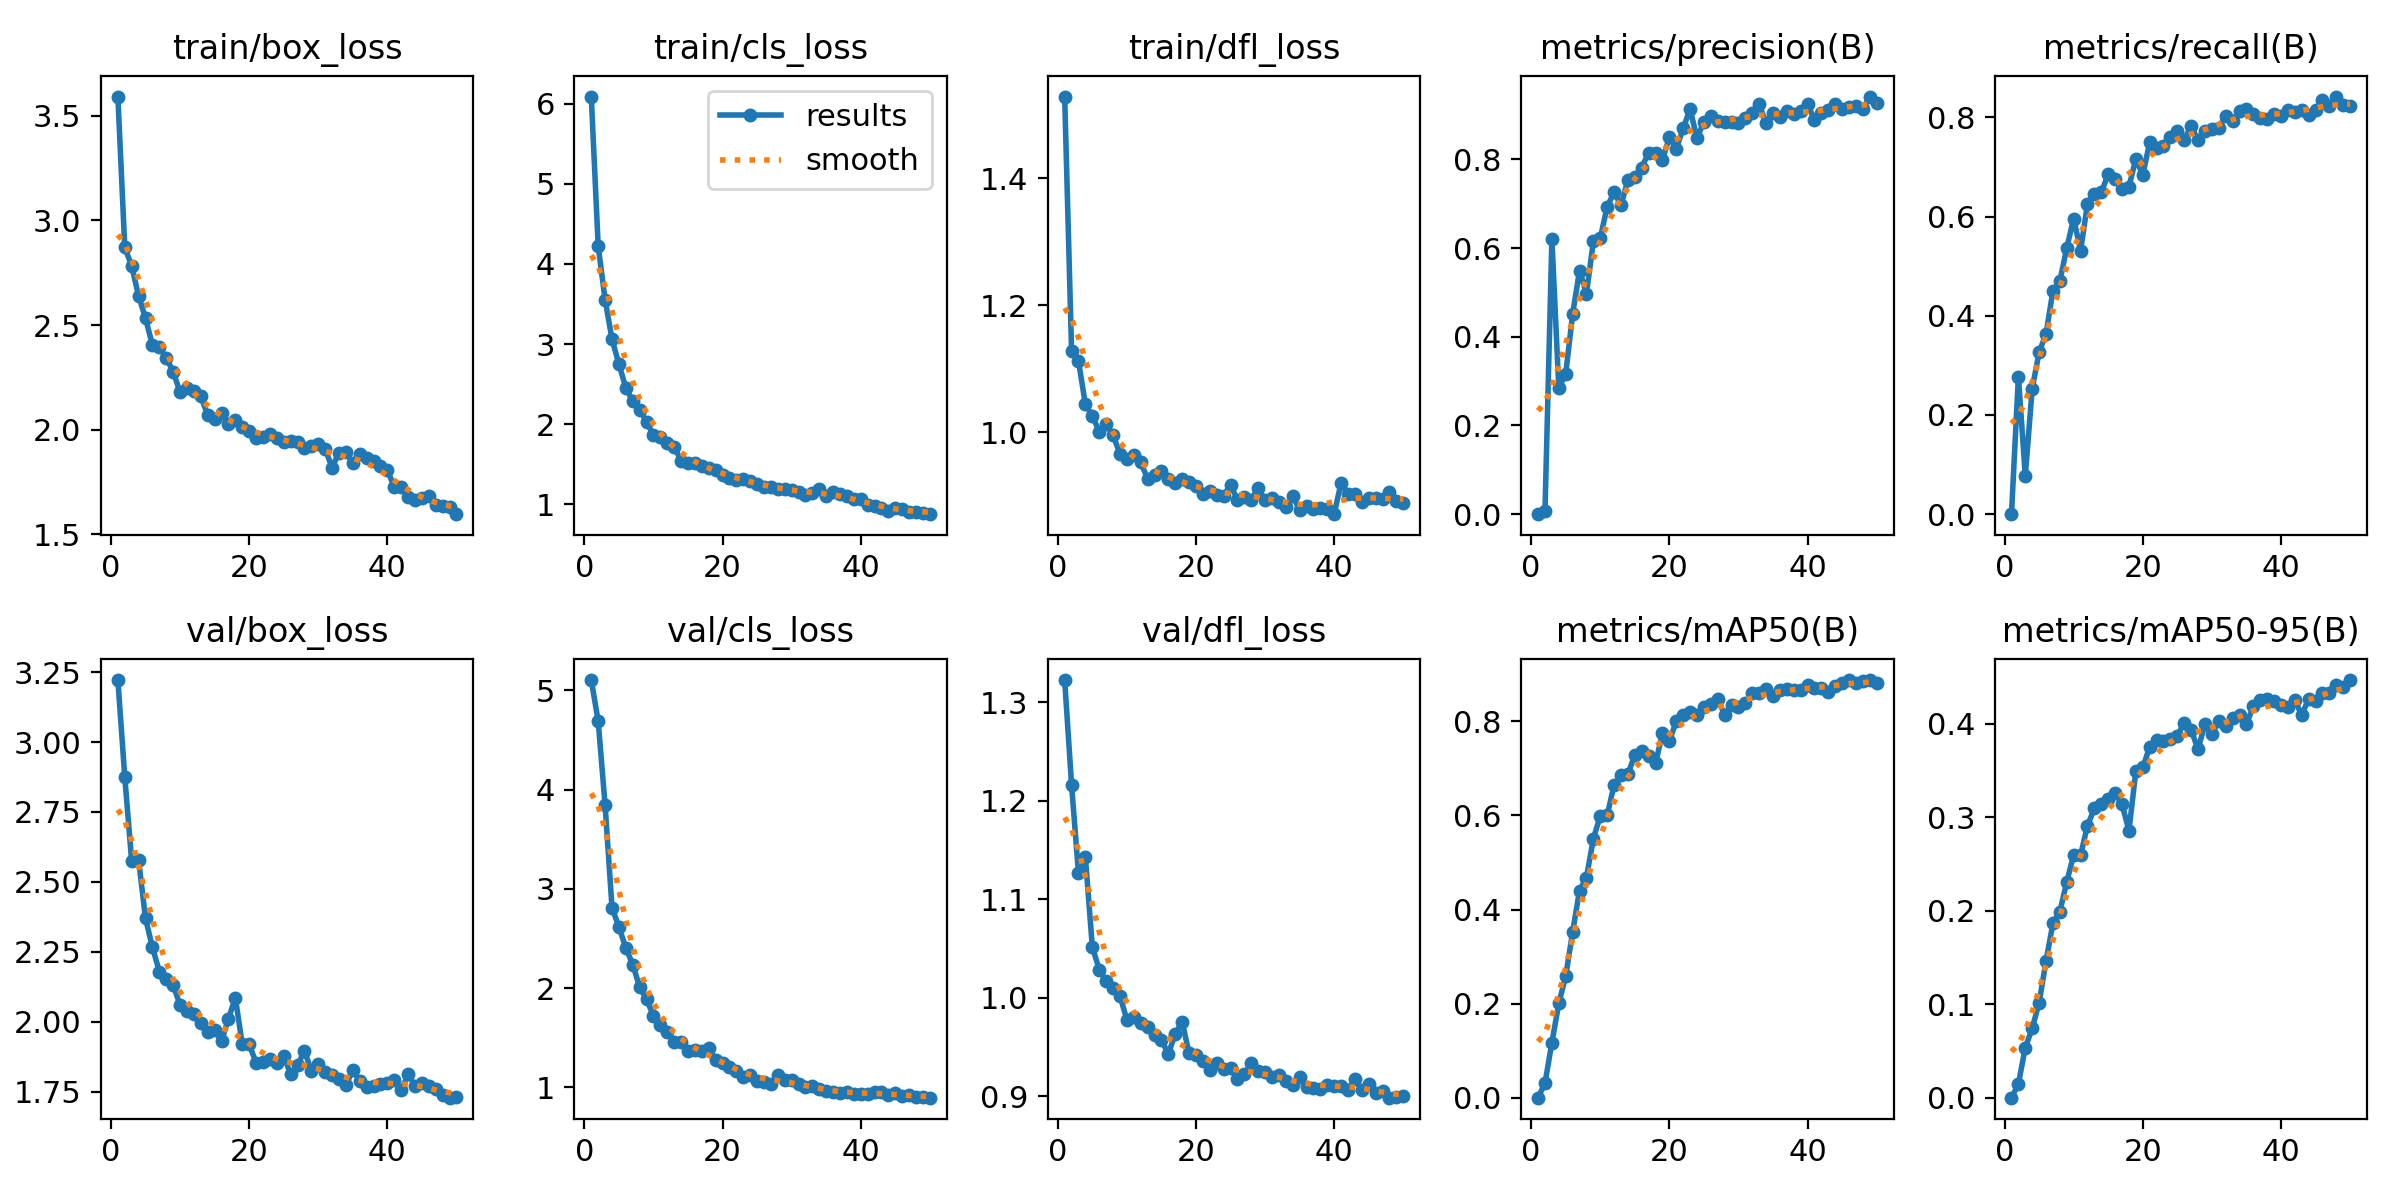

In [16]:
from IPython.display import Image, display
import os
import glob

# Tìm đường dẫn thư mục runs gần đây nhất vừa huấn luyện xong
runs_dirs = glob.glob("runs/detect/runs/apex_inspect/yolov8n_pcb_custom*")
if not runs_dirs:
    # Đề phòng lưu ở thư mục gốc mặc định
    runs_dirs = glob.glob("runs/apex_inspect/yolov8n_pcb_custom*")

if runs_dirs:
    # Lấy thư mục mới nhất
    latest_run_dir = sorted(runs_dirs)[-1]
    print(f"📂 Thư mục chứa kết quả huấn luyện mới nhất: {latest_run_dir}\n")

    # Hiển thị ma trận nhầm lẫn (Confusion Matrix)
    conf_matrix_path = os.path.join(latest_run_dir, "confusion_matrix.png")
    if os.path.exists(conf_matrix_path):
        print("📊 Ma trận nhầm lẫn (Confusion Matrix):")
        display(Image(filename=conf_matrix_path))
    else:
        print("⚠️ Không tìm thấy file confusion_matrix.png")

    # Hiển thị biểu đồ kết quả mAP và Loss
    results_path = os.path.join(latest_run_dir, "results.png")
    if os.path.exists(results_path):
        print("📈 Đồ thị huấn luyện (Loss & mAP Curves):")
        display(Image(filename=results_path))
    else:
        print("⚠️ Không tìm thấy file results.png")
else:
    print("❌ Không tìm thấy bất kỳ thư mục kết quả huấn luyện nào ở cả hai đường dẫn cấu hình!")

## Bước 5: Tối Ưu Hóa & Xuất Sang Định Dạng ONNX (Edge Deployment)
Chuyển đổi trọng số `best.pt` sang định dạng `ONNX` kèm tối ưu hóa đồ thị tính toán (Graph Optimization).

In [17]:
import os
import glob
import shutil
from ultralytics import YOLO

# Tìm đường dẫn thư mục runs gần đây nhất vừa huấn luyện xong để lấy file weights tốt nhất
runs_dirs = glob.glob("runs/detect/runs/apex_inspect/yolov8n_pcb_custom*")
if not runs_dirs:
    runs_dirs = glob.glob("runs/apex_inspect/yolov8n_pcb_custom*")

best_model_path = "yolov8n.pt"
if runs_dirs:
    latest_run_dir = sorted(runs_dirs)[-1]
    candidate_path = os.path.join(latest_run_dir, "weights/best.pt")
    if os.path.exists(candidate_path):
        best_model_path = candidate_path

print(f"🎯 Đang sử dụng trọng số tốt nhất từ: {best_model_path}")
custom_model = YOLO(best_model_path)

# Xuất sang ONNX (loại bỏ tham số optimize không tương thích và half đã cũ)
onnx_path = custom_model.export(format="onnx", imgsz=640)
print(f"✅ Mô hình ONNX đã xuất thành công tại: {onnx_path}")

# Sao chép mô hình vào thư mục models/ của dự án ApexInspect AI
target_onnx = "../../models/yolov8n_pcb_defect.onnx"
if os.path.exists(os.path.dirname(target_onnx)):
    shutil.copy2(onnx_path, target_onnx)
    print(f"🚀 Đã cập nhật mô hình vào dự án: {target_onnx}")
else:
    print(f"💡 Mẹo: Bạn có thể tải file '{onnx_path}' về máy tính và đặt vào thư mục 'models/yolov8n_pcb_defect.onnx' của dự án.")

🎯 Đang sử dụng trọng số tốt nhất từ: runs/detect/runs/apex_inspect/yolov8n_pcb_custom-4/weights/best.pt
Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/runs/apex_inspect/yolov8n_pcb_custom-4/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 271ms
Prepared 4 packages in 1.00s
Installed 4 packages in 273ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.30.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 2.0s
WARNING ⚠️ requirements: Rest